In [1]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
from ctd.comparison.analysis.dd.dd import Analysis_DD
from ctd.comparison.comparison import Comparison
import dotenv
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
# import environment variables
dotenv.load_dotenv(override=True)
HOME_DIR = os.getenv("HOME_DIR")


# Compare TT-DD for PC

## NODE TT, NODE DD for allRates

1. Inputs provided
2. How do you even deal w/ not inputs provided - surely one can not compare in DSA inputs vs non inputs

PRETENDING LIKE I'M COMPARING DD TO TT NODE BUT ALL IS FROM TUNING RUN OF TT - NEED TO COMPLETE

one TT is ref rest should be DD

In [4]:
node2_tt = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_NODE_grid_allRates/max_epochs=800_weight_decay=1.00E-08_learning_rate=2.00E-03_seed=0_noise=0.00E+00_allRates=True_latent_size=2_layer_hidden_size=64_latent_l2_wt=1.00E-08/"

node2_tt = Analysis_TT(run_name = "node2_tt", filepath= node2_tt)  

# from lat2 sim
dd_lat2 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=13']

# from lat3 sim
dd_lat3 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=52']

# form lat5 sim
dd_lat5 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=66']

node_tt_2_node = Comparison(comparison_tag = "node_pc")
node_tt_2_node.load_analysis(node2_tt, group = "node2_tt", reference_analysis=True)
lat_sizes = []

# for subfolder in dd_lat2:
lat = [2,3,5]
dd_sweep = "/scratch/gpfs/ad2002/content/trained_models/task-trained/tt_PClicks/20250325_NODE_on_PC_NODE_false/"
for index, subfolder in enumerate([dd_lat2, dd_lat3, dd_lat5]):
    subfolder = dd_sweep + subfolder[0] + "/"
    #lat_size = int(subfolder.split("latent_size=")[1].split("_")[0])
    ana_dd = Analysis_DD.create(run_name = f"node_from_{lat[index]}", filepath = subfolder, model_type = "SAE")
    # print(f"NODE_{lat_size}")
    # lat_sizes.append(lat_size)
    node_tt_2_node.load_analysis(ana_dd, group = "node2_tt")

/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [5]:
# metrics + DSA - expect to not be similar - comparing allrates to only trained on one rate - same latent size

metric_list = ["state_r2", "rate_r2", 'co-bps', 'cycle_con']
metrics_node_tt_2_node = node_tt_2_node.compute_metrics(metric_list=metric_list, cycle_con_var=0.01)


Working on 1 of 4: node2_tt

Working on 2 of 4: node_from_2
State R2: 0.307752788066864
Rate R2: 0.9979154467582703
CO-BPS: 0.11507971584796906
Cycle Consistency R2: 0.9998905062675476

Working on 3 of 4: node_from_3
State R2: 0.29597213864326477
Rate R2: 0.9987196326255798
CO-BPS: 0.13817568123340607
Cycle Consistency R2: 0.9998569488525391

Working on 4 of 4: node_from_5
State R2: 0.31610310077667236
Rate R2: 0.9951621294021606
CO-BPS: 0.1162705048918724
Cycle Consistency R2: 0.9997961521148682


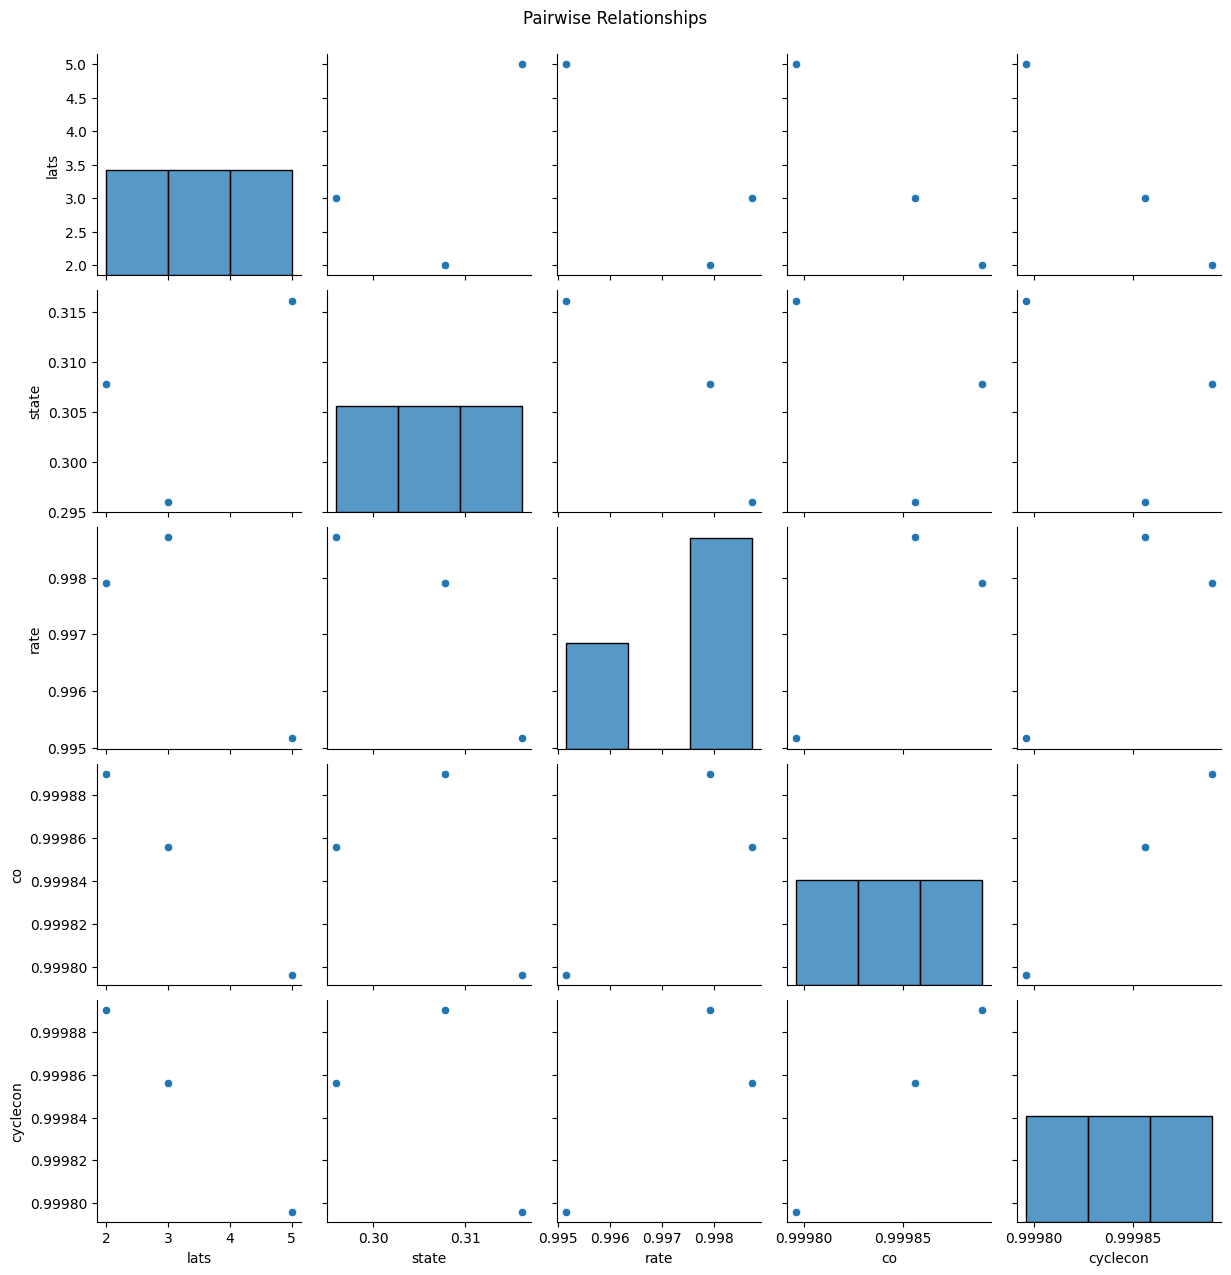

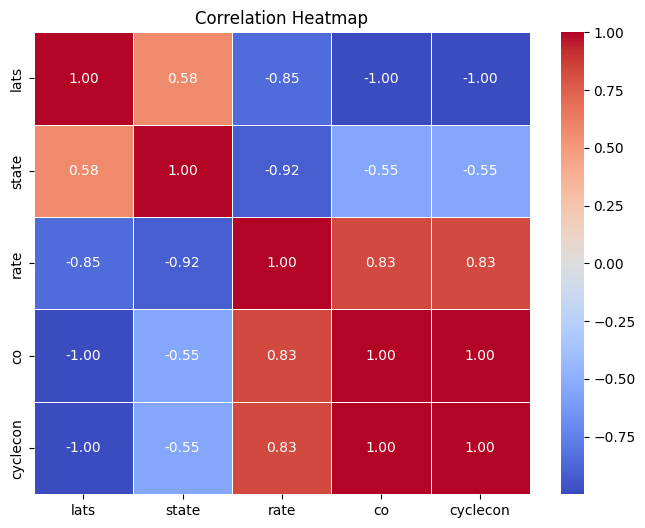

Correlation Matrix:
               lats     state      rate        co  cyclecon
lats      1.000000  0.577539 -0.851394 -0.999482 -0.999482
state     0.577539  1.000000 -0.919918 -0.550954 -0.550954
rate     -0.851394 -0.919918  1.000000  0.834063  0.834063
co       -0.999482 -0.550954  0.834063  1.000000  1.000000
cyclecon -0.999482 -0.550954  0.834063  1.000000  1.000000


In [10]:
lats = [2,3,5]
state = [0.30775,0.295972,0.31610 ]
rate = [0.99791,0.998719, 0.995162]
co = [0.99989, 0.999856, 0.9997961]
cyclecon = [0.999890, 0.999856, 0.9997961]

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame
data = pd.DataFrame({
    'lats': lats,
    'state': state,
    'rate': rate,
    'co': co,
    'cyclecon': cyclecon
})

# Pairplot to show pairwise relationships
sns.pairplot(data)
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Heatmap to show correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Optionally, calculate other interesting metrics like pairwise correlation values
print("Correlation Matrix:\n", correlation_matrix)


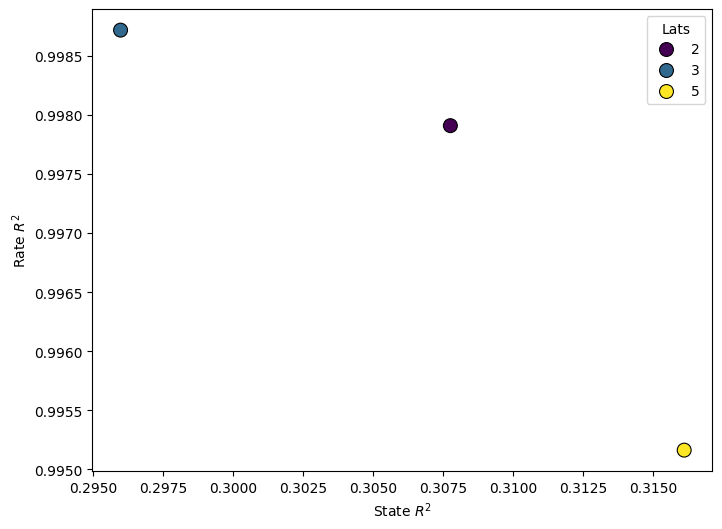

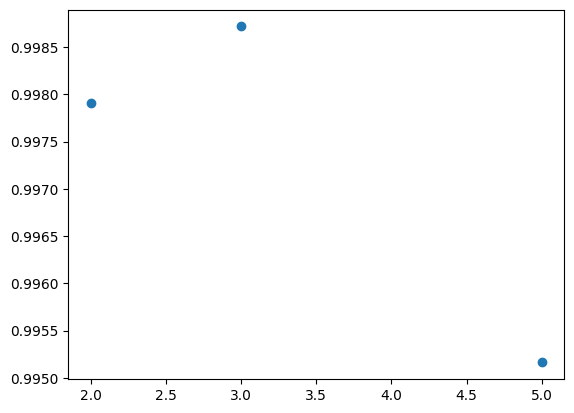

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data
lats = [2, 3, 5]
state = [0.30775, 0.295972, 0.31610]
rate = [0.99791, 0.998719, 0.995162]
co = [0.99989, 0.999856, 0.9997961]
cyclecon = [0.999890, 0.999856, 0.9997961]

# Create a DataFrame
data = pd.DataFrame({
    'lats': lats,
    'state': state,
    'rate': rate,
    'co': co,
    'cyclecon': cyclecon
})

# Scatter plot where y is 'rate', x is 'state', and points are colored by 'lats'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='state', y='rate', hue='lats', palette='viridis', s=100, edgecolor='black')


plt.xlabel("State $R^2$")
plt.ylabel("Rate $R^2$")

# Display the plot
plt.legend(title='Lats')
plt.show()

plt.scatter(lats, rate)


Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

computing similarity between DMDs 1 and 0


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 2
Finished optimizing C
Finished optimizing C


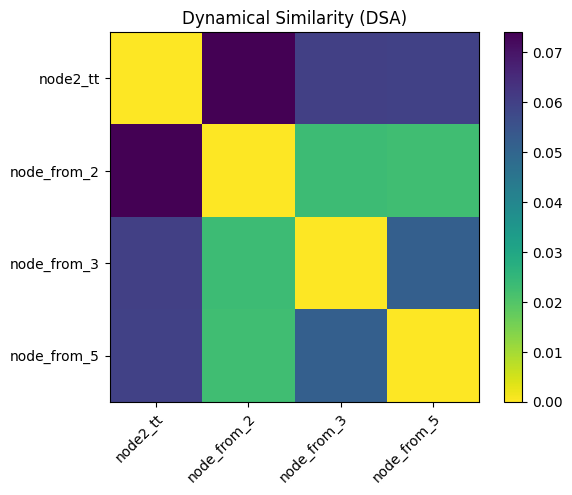

In [8]:
similarities = node_tt_2_node.compare_dynamics_DSA(phase="val",
                                                    n_delays=25,
                                                    rank=50,
                                                    delay_interval=1,
                                                    device="cpu",
                                                    percent_data=0.01,
                                                    reduce_all_latents=True,
                                                  )

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

computing similarity between DMDs 1 and 0


/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 2
Finished optimizing C
Finished optimizing C


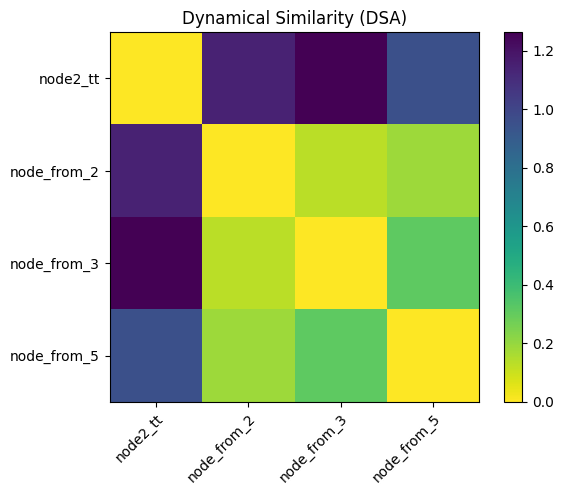

In [9]:
similarities = node_tt_2_node.compare_dynamics_DSA(phase="val",
                                                    n_delays=50,
                                                    rank=100,
                                                    delay_interval=1,
                                                    device="cpu",
                                                    percent_data=0.01,
                                                    reduce_all_latents=True,
                                                  )

## NODE TT, NODE DD

1. Easiest trials: 0 noise, 39:1, sizes: 2,3,5, inputs provided


DO: sweep through noise levels, sweep through latents, both for and w/o inputs. 0.75 error already has good reconstruction

In [2]:
tt_path = HOME_DIR + "content/trained_models/task-trained/"
tt_sweep = "20250323_PClicks_NODE_grid/"
lat2 = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0_rateL=39_latent_size=2_layer_hidden_size=128_latent_l2_wt=1.00E-08" 
lat3 = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0_rateL=39_latent_size=3_layer_hidden_size=128_latent_l2_wt=1.00E-08" 
lat5 = "max_epochs=1000_weight_decay=1.00E-09_learning_rate=1.00E-03_seed=0_noise=0_rateL=39_latent_size=5_layer_hidden_size=128_latent_l2_wt=1.00E-08"

l2 = Analysis_TT(run_name = "lat2_node_pc", filepath= tt_path + tt_sweep + lat2 + "/")  #13
l3 = Analysis_TT(run_name = "lat3_node_pc", filepath= tt_path + tt_sweep + lat3 + "/")  #52
l5 = Analysis_TT(run_name = "lat5_node_pc", filepath= tt_path + tt_sweep + lat5 + "/")  #66
# l2.plot_trial_io(num_trials= 5)
# l3.plot_trial_io(num_trials= 5)
# l5.plot_trial_io(num_trials= 5)

Analysis_DD has access to the TT datamodule and uses it to get the metrics
* metrics taken over val phase

* for metrics, group different models (lat, noise) coming from the same sim TT model (one ref)

* for DSA, group same models (latents), can be different noise, architecture, from same/diff sim TT model (one ref)

In [3]:
dd_sweep = "tt_PClicks/20250325_NODE_on_PC_NODE_false/"

# from lat2 sim
dd_lat2 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=13']#,
# 'prefix=20250323_PClicks_NODE_grid_latent_size=3_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=13']

# from lat3 sim
dd_lat3 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=52']

# form lat5 sim
dd_lat5 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=66']

comp_node_lat2 = Comparison(comparison_tag = "node_pc")
comp_node_lat2.load_analysis(l2, group = "tt_lat2_node_pc", reference_analysis=True)
lat_sizes = []

# for subfolder in dd_lat2:
lat = [2,3,5]
for index, subfolder in enumerate([dd_lat2, dd_lat3, dd_lat5]):
    subfolder = tt_path + dd_sweep + subfolder[0] + "/"
    #lat_size = int(subfolder.split("latent_size=")[1].split("_")[0])
    ana_node_lat2 = Analysis_DD.create(run_name = f"node_from_{lat[index]}", filepath = subfolder, model_type = "SAE")
    # print(f"NODE_{lat_size}")
    # lat_sizes.append(lat_size)
    comp_node_lat2.load_analysis(ana_node_lat2, group = "tt_lat2_node_pc")

/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [4]:
# all DD latent size 2, from diff TT lat sizes
metric_list = ["state_r2", "rate_r2", 'co-bps', 'cycle_con']
metrics_node_lat2 = comp_node_lat2.compute_metrics(metric_list=metric_list, cycle_con_var=0.01)


Working on 1 of 4: lat2_node_pc

Working on 2 of 4: node_from_2
State R2: 0.9961092472076416
Rate R2: 0.9979206323623657
CO-BPS: 0.11508102715015411
Cycle Consistency R2: 0.9998958706855774

Working on 3 of 4: node_from_3
State R2: 0.9995246529579163
Rate R2: 0.9986978769302368
CO-BPS: 0.138174906373024
Cycle Consistency R2: 0.9998559355735779

Working on 4 of 4: node_from_5
State R2: 0.9852018356323242
Rate R2: 0.9951635599136353
CO-BPS: 0.11627038568258286
Cycle Consistency R2: 0.9998025894165039


In [4]:
# DD diff latent sizes, fromk TT latent size 2
metric_list = ["state_r2", "rate_r2", 'co-bps', 'cycle_con']
metrics_node_lat2 = comp_node_lat2.compute_metrics(metric_list=metric_list, cycle_con_var=0.01)


Working on 1 of 3: lat2_node_pc

Working on 2 of 3: node_2
State R2: 0.996151328086853
Rate R2: 0.9979293942451477
CO-BPS: 0.11508277803659439
Cycle Consistency R2: 0.9999023079872131

Working on 3 of 3: node_3
State R2: 0.9929505586624146
Rate R2: 0.9988576769828796
CO-BPS: 0.11542218178510666
Cycle Consistency R2: 0.9964902997016907


In [14]:
                # X,
                # Y=None,
                # n_delays=1,
                # delay_interval=1,
                # rank=None,
                # rank_thresh=None,
                # rank_explained_variance = None,
                # lamb = 0.0,
                # send_to_cpu = True,
                # iters = 1500,
                # score_method: Literal["angular", "euclidean","wasserstein"] = "angular",
                # lr = 5e-3,
                # group: Literal["GL(n)", "O(n)", "SO(n)"] = "O(n)",
                # zero_pad = False,
                # device = 'cpu',
                # verbose = False,
                # reduced_rank_reg = False,
                # kernel=None,
                # num_centers=0.1,
                # svd_solver='arnoldi',
                # wasserstein_compare: Literal['sv','eig',None] = None

        # Parameters
        # __________

        # X : np.array or torch.tensor or list of np.arrays or torch.tensors
        #     first data matrix/matrices
        
        # Y : None or np.array or torch.tensor or list of np.arrays or torch.tensors
        #     second data matrix/matrices. 
        #     * If Y is None, X is compared to itself pairwise 
        #     (must be a list)
        #     * If Y is a single matrix, all matrices in X are compared to Y
        #     * If Y is a list, all matrices in X are compared to all matrices in Y
        
        # DMD parameters: 

        # n_delays : int or list or tuple/list: (int,int), (list,list),(list,int),(int,list)
        #     number of delays to use in constructing the Hankel matrix
        
        # delay_interval : int or list or tuple/list: (int,int), (list,list),(list,int),(int,list)
        #     interval between samples taken in constructing Hankel matrix

        # rank : int or list or tuple/list: (int,int), (list,list),(list,int),(int,list)
        #     rank of DMD matrix fit in reduced-rank regression
        
        # rank_thresh : float or list or tuple/list: (float,float), (list,list),(list,float),(float,list)
        #     Parameter that controls the rank of V in fitting HAVOK DMD by dictating a threshold
        #     of singular values to use. Explicitly, the rank of V will be the number of singular
        #     values greater than rank_thresh. Defaults to None.
        
        # rank_explained_variance : float or list or tuple: (float,float), (list,list),(list,float),(float,list)
        #     Parameter that controls the rank of V in fitting HAVOK DMD by indicating the percentage of
        #     cumulative explained variance that should be explained by the columns of V. Defaults to None.
        
        # lamb : float
        #     L-1 regularization parameter in DMD fit
        
        # send_to_cpu: bool
        #     If True, will send all tensors in the object back to the cpu after everything is computed.
        #     This is implemented to prevent gpu memory overload when computing multiple DMDs.

        # NOTE: for all of these above, they can be single values or lists or tuples,
        #     depending on the corresponding dimensions of the data
        #     If at least one of X and Y are lists, then if they are a single value
        #         it will default to the rank of all DMD matrices. 
        #     If they are (int,int), then they will correspond to an individual dmd matrix
        #         OR to X and Y respectively across all matrices
        #     If it is (list,list), then each element will correspond to an individual
        #         dmd matrix indexed at the same position

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

Computing Hankel matrix ...
Hankel matrix computed!
Computing SVD on Hankel matrix ...
SVD complete!
Computing least squares fits to HAVOK DMD ...
Least squares complete! 

computing similarity between DMDs 1 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 0
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 2 and 1
Finished optimizing C
Finished optimizing C
computing similarity between DMDs 3 and 0
Finished

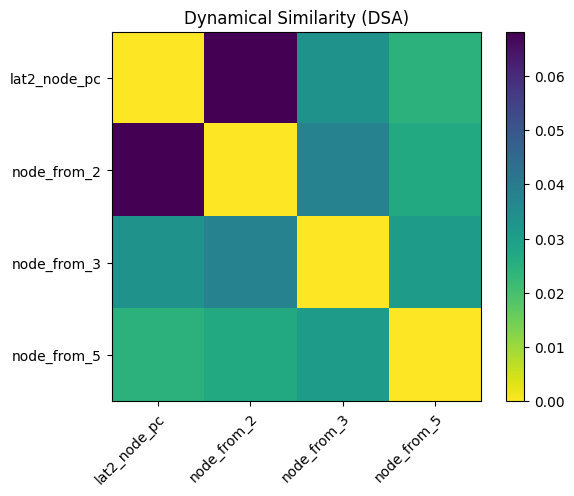

In [6]:
similarities = comp_node_lat2.compare_dynamics_DSA(phase="val",
                                                    n_delays=20,
                                                    rank=50,
                                                    delay_interval=1,
                                                    device="cpu",
                                                    percent_data=0.01,
                                                    reduce_all_latents=True,
                                                  )

In [7]:
print(similarities)

# from the same TT model, a gainst itself at size 2
# [[0.         0.02385649]
#  [0.02385649 0.        ]]

[[0.         0.06811396 0.0333122  0.02437802]
 [0.06811396 0.         0.03797537 0.02674729]
 [0.0333122  0.03797537 0.         0.03057828]
 [0.02437802 0.02674729 0.03057828 0.        ]]


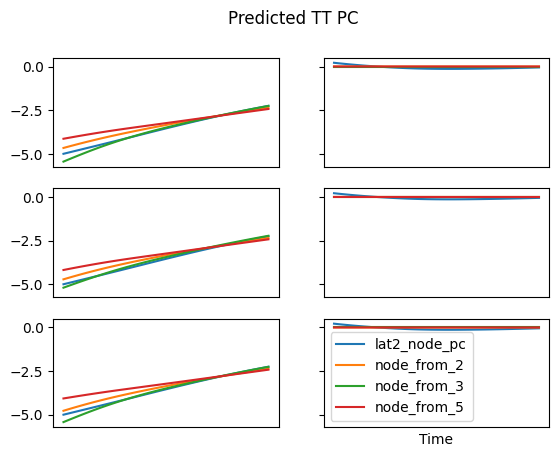

In [13]:
comp_node_lat2.plot_trials_reference_dims(num_trials=3,dims=[0,1])

In [ ]:
# # from lat3 sim
# dd_lat3 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=52']

# # form lat5 sim
# dd_lat5 = ['prefix=20250323_PClicks_NODE_grid_latent_size=2_max_epochs=500_seed=0_lr=1.00E-03_weight_decay=1.00E-06_file_index=66']

In [6]:

lat_sizes, metrics_NODE["state_r2"], metrics_NODE["rate_r2"], metrics_NODE["co-bps"], metrics_NODE['cycle_con'] = zip(*sorted(zip(lat_sizes, metrics_NODE["state_r2"], metrics_NODE["rate_r2"], metrics_NODE["co-bps"], metrics_NODE['cycle_con'])))


In [7]:
metrics = ["state_r2", "rate_r2", "co-bps", "cycle_con"]
mean_metrics = {k:[] for k in metrics}
for lat in np.unique(lat_sizes):
    for met in metrics:
        met_list = np.array(metrics_NODE[met])
        lat_met = met_list[lat_sizes == lat]
        mean_metrics[met].append([lat, np.mean(lat_met)])

for met in metrics:
    mean_metrics[met] = np.array(mean_metrics[met])

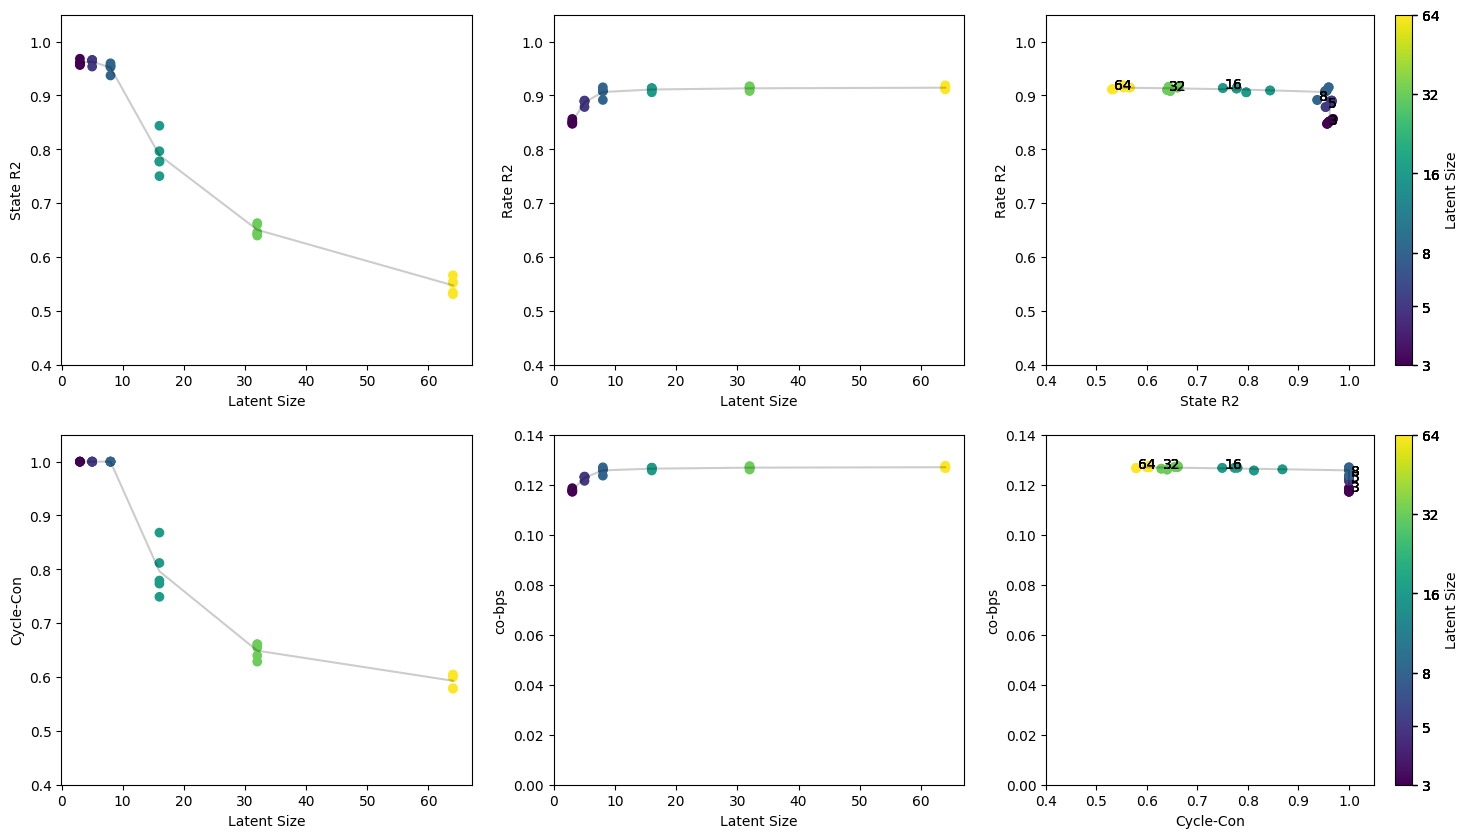

In [8]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0,0].scatter(lat_sizes, metrics_NODE["state_r2"], c = np.log10(lat_sizes))
ax[0,0].plot(mean_metrics['state_r2'][:,0],mean_metrics['state_r2'][:,1], c= 'k', alpha=0.2)
ax[0,0].set_xlabel("Latent Size")
ax[0,0].set_ylabel("State R2")
ax[0,0].set_ylim(0.4, 1.05)

ax[0,1].scatter(lat_sizes, metrics_NODE["rate_r2"], c = np.log10(lat_sizes))
ax[0,1].plot(mean_metrics['rate_r2'][:,0], mean_metrics['rate_r2'][:,1], c= 'k', alpha=0.2)
ax[0,1].set_xlabel("Latent Size")
ax[0,1].set_ylabel("Rate R2")
ax[0,1].set_ylim(0.4, 1.05)

ax[0,2].scatter(metrics_NODE["state_r2"], metrics_NODE["rate_r2"], c=np.log10(lat_sizes))
ax[0,2].plot(mean_metrics['state_r2'][:,1], mean_metrics['rate_r2'][:,1], c= 'k', alpha=0.2)
ax[0,2].set_xlabel("State R2")
ax[0,2].set_ylabel("Rate R2")
ax[0,2].set_xlim(0.4, 1.05)
ax[0,2].set_ylim(0.4, 1.05)

# add colorbar with ticks for each latent size
cbar = plt.colorbar(ax[0,2].scatter(metrics_NODE["state_r2"], metrics_NODE["rate_r2"], c=np.log10(lat_sizes)))
cbar.set_label("Latent Size")
cbar.set_ticks(np.log10(lat_sizes))
cbar.set_ticklabels(lat_sizes)

for lat_size in lat_sizes:
    ax[0,2].text(metrics_NODE["state_r2"][lat_sizes.index(lat_size)]+0.004, metrics_NODE["rate_r2"][lat_sizes.index(lat_size)], str(lat_size))


# Non-ground-truth metrics
ax[1,0].scatter(lat_sizes, metrics_NODE["cycle_con"], c = np.log10(lat_sizes))
ax[1,0].plot(mean_metrics['cycle_con'][:,0], mean_metrics['cycle_con'][:,1], c= 'k', alpha=0.2)
ax[1,0].set_xlabel("Latent Size")
ax[1,0].set_ylabel("Cycle-Con")
ax[1,0].set_ylim(0.4, 1.05)

ax[1,1].scatter(lat_sizes, metrics_NODE["co-bps"], c = np.log10(lat_sizes))
ax[1,1].plot(mean_metrics['co-bps'][:,0], mean_metrics['co-bps'][:,1], c= 'k', alpha=0.2)
ax[1,1].set_xlabel("Latent Size")
ax[1,1].set_ylabel("co-bps")
ax[1,1].set_ylim(0.0, 0.14)

ax[1,2].scatter(metrics_NODE["cycle_con"], metrics_NODE["co-bps"], c=np.log10(lat_sizes))
ax[1,2].plot(mean_metrics['cycle_con'][:,1], mean_metrics['co-bps'][:,1], c= 'k', alpha=0.2)
ax[1,2].set_xlabel("Cycle-Con")
ax[1,2].set_ylabel("co-bps")
ax[1,2].set_xlim(0.4, 1.05)
ax[1,2].set_ylim(0.0, 0.14)

# add colorbar with ticks for each latent size
cbar = plt.colorbar(ax[1,2].scatter(metrics_NODE["cycle_con"], metrics_NODE["co-bps"], c=np.log10(lat_sizes)))
cbar.set_label("Latent Size")
cbar.set_ticks(np.log10(lat_sizes))
cbar.set_ticklabels(lat_sizes)

for lat_size in lat_sizes:
    ax[1,2].text(metrics_NODE["cycle_con"][lat_sizes.index(lat_size)]+0.004, metrics_NODE["co-bps"][lat_sizes.index(lat_size)], str(lat_size))



(0.0, 0.14)

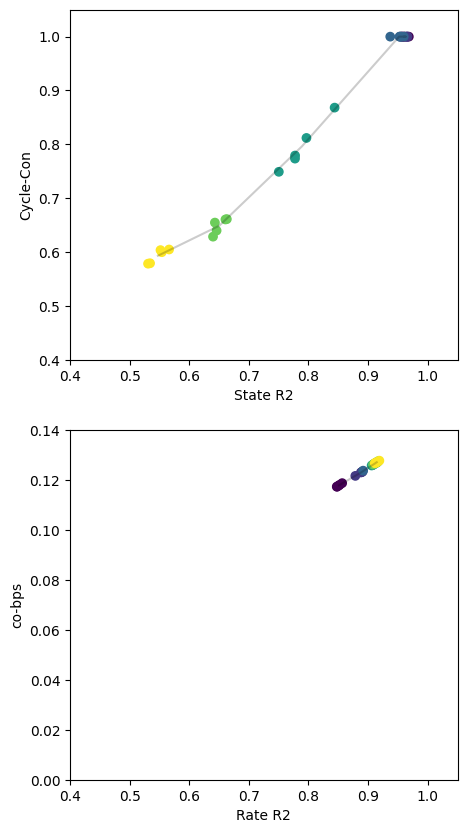

In [9]:
fig = plt.figure(figsize=(5, 10))
ax =fig.add_subplot(211)
ax.scatter(metrics_NODE["state_r2"], metrics_NODE["cycle_con"], c=np.log10(lat_sizes))
ax.plot(mean_metrics['state_r2'][:,1], mean_metrics['cycle_con'][:,1], c= 'k', alpha=0.2)
ax.set_xlabel("State R2")
ax.set_ylabel("Cycle-Con")
ax.set_xlim(0.4, 1.05)
ax.set_ylim(0.4, 1.05)

ax =fig.add_subplot(212)
ax.scatter(metrics_NODE["rate_r2"], metrics_NODE["co-bps"], c=np.log10(lat_sizes))
ax.plot(mean_metrics['rate_r2'][:,1], mean_metrics['co-bps'][:,1], c= 'k', alpha=0.2)
ax.set_xlabel("Rate R2")
ax.set_ylabel("co-bps")
ax.set_xlim(0.4, 1.05)
ax.set_ylim(0.0, 0.14)


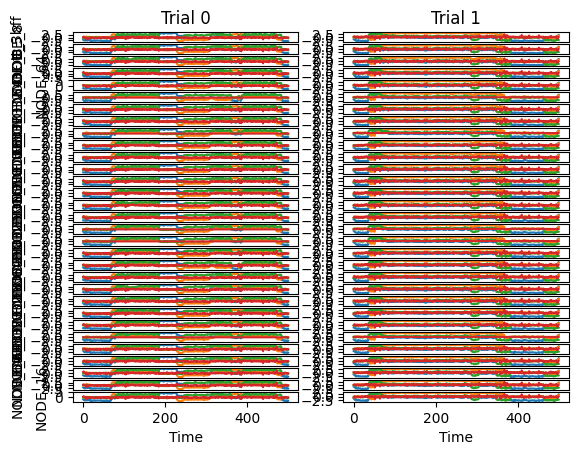

In [10]:
comparison_NODE.plot_trials_reference()